
# Descriptive Statistics — 1-Hour Hands-On Colab



**SETUP**

The answers for the last section are answered at the bottom.


In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

np.random.seed(42)


In [9]:

n = 120

age = np.random.randint(18, 61, n)
income = np.random.normal(55000, 15000, n).clip(20000, 120000)
purchases = np.random.poisson(5, n) + 1
spending = (income * np.random.uniform(0.02, 0.10, n) +
            purchases * np.random.uniform(150, 500, n))

satisfaction = np.random.normal(7, 1.2, n).clip(1, 10)

df = pd.DataFrame({
    "Customer_ID": range(1, n + 1),
    "Age": age,
    "Monthly_Income": income.round(0),
    "Purchases": purchases,
    "Total_Spending": spending.round(0),
    "Satisfaction_Score": satisfaction.round(1)
})

# Add a few realistic high-spending customers
df.loc[[10, 45, 90], "Total_Spending"] *= [4, 5, 6]

df.head()


,Customer_ID,Age,Monthly_Income,Purchases,Total_Spending,Satisfaction_Score
0,1,56,"40,994.00",8,"3,041.00",6.20
1,2,46,"66,763.00",6,"7,589.00",6.80
2,3,32,"45,777.00",8,"5,116.00",6.50
3,4,60,"59,993.00",5,"7,515.00",8.40
4,5,25,"34,289.00",5,"3,686.00",6.30


In [10]:
df.shape

# Your answer after running:
# Customers = ?
# Variables = ?

(120, 6)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         120 non-null    int64  
 1   Age                 120 non-null    int64  
 2   Monthly_Income      120 non-null    float64
 3   Purchases           120 non-null    int64  
 4   Total_Spending      120 non-null    float64
 5   Satisfaction_Score  120 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 5.8 KB


In [12]:

mean_spending = df["Total_Spending"].mean()
print(f"Mean spending = ₹{mean_spending:,.2f}")


Mean spending = ₹5,938.93


In [13]:

print(f"Minimum spending = ₹{df['Total_Spending'].min():,.2f}")
print(f"Maximum spending = ₹{df['Total_Spending'].max():,.2f}")


Minimum spending = ₹1,299.00
Maximum spending = ₹37,096.00


In [14]:

median_spending = df["Total_Spending"].median()
print(f"Median spending = ₹{median_spending:,.2f}")


Median spending = ₹5,157.00


In [15]:

print("Purchase count frequencies:")
print(df["Purchases"].value_counts().sort_index())

mode_purchases = df["Purchases"].mode()[0]
print(f"Most common number of purchases = {mode_purchases}")


Purchase count frequencies:
Purchases
1      1
2      4
3      9
4     15
5     28
6     16
7     12
8     19
9      6
10     5
11     2
12     1
13     2
Name: count, dtype: int64
Most common number of purchases = 5



## Mini Exercise 1 — Central Tendency

Use the `Age` column.

Calculate:
1. Mean age
2. Median age
3. Mode age

Then answer:

> Are mean and median close? What does that suggest about the age distribution?


In [16]:


mean_age = df["Age"].mean()
median_age = df["Age"].median()
mode_age = df["Age"].mode()[0]

print("Mean age:", mean_age)
print("Median age:", median_age)
print("Mode age:", mode_age)


Mean age: 38.36666666666667
Median age: 39.0
Mode age: 41


In [17]:

income_range = df["Monthly_Income"].max() - df["Monthly_Income"].min()
print(f"Income range = ₹{income_range:,.2f}")


Income range = ₹69,100.00


In [18]:

income_variance = df["Monthly_Income"].var()
print(f"Sample variance of monthly income = {income_variance:,.2f}")


Sample variance of monthly income = 213,227,749.22


In [19]:

income_std = df["Monthly_Income"].std()
print(f"Income standard deviation = ₹{income_std:,.2f}")


Income standard deviation = ₹14,602.32



## Mini Exercise 2 — Compare Two Groups

Create two artificial spending groups:

- Group A: low variation
- Group B: high variation

Calculate the mean and standard deviation of both.

### Question
Can two groups have approximately the same mean but very different standard deviations?


In [20]:

group_a = np.array([48, 49, 50, 51, 52])
group_b = np.array([10, 30, 50, 70, 90])

print("Group A")
print("Mean:", group_a.mean())
print("Std:", group_a.std(ddof=1))

print("\nGroup B")
print("Mean:", group_b.mean())
print("Std:", group_b.std(ddof=1))


Group A
Mean: 50.0
Std: 1.5811388300841898

Group B
Mean: 50.0
Std: 31.622776601683793


In [21]:

q1 = df["Total_Spending"].quantile(0.25)
median = df["Total_Spending"].quantile(0.50)
q3 = df["Total_Spending"].quantile(0.75)

print(f"25th percentile (Q1) = ₹{q1:,.2f}")
print(f"50th percentile (Median) = ₹{median:,.2f}")
print(f"75th percentile (Q3) = ₹{q3:,.2f}")


25th percentile (Q1) = ₹4,059.00
50th percentile (Median) = ₹5,157.00
75th percentile (Q3) = ₹6,871.00


In [22]:

iqr = q3 - q1
print(f"IQR = ₹{iqr:,.2f}")


IQR = ₹2,812.00


In [23]:

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[
    (df["Total_Spending"] < lower_bound) |
    (df["Total_Spending"] > upper_bound)
]

print(f"Lower bound = ₹{lower_bound:,.2f}")
print(f"Upper bound = ₹{upper_bound:,.2f}")
print(f"Number of possible outliers = {len(outliers)}")

outliers[["Customer_ID", "Age", "Monthly_Income", "Total_Spending"]]


Lower bound = ₹-159.00
Upper bound = ₹11,089.00
Number of possible outliers = 3


,Customer_ID,Age,Monthly_Income,Total_Spending
10,11,28,"59,465.00","37,096.00"
45,46,37,"39,181.00","25,450.00"
90,91,34,"52,796.00","26,892.00"


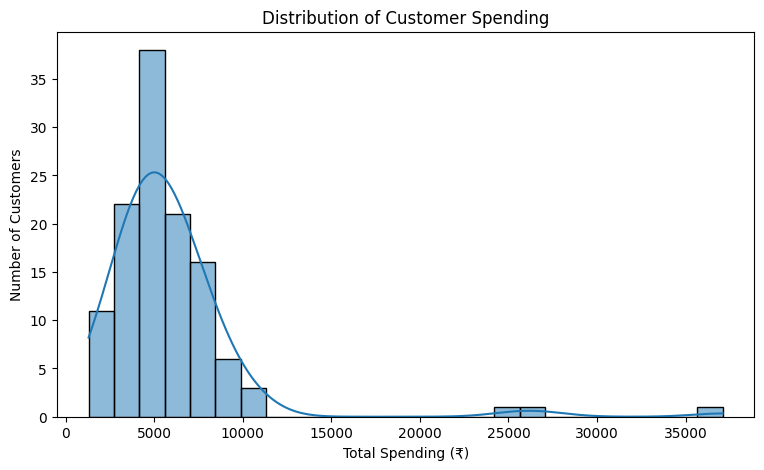

In [24]:

plt.figure(figsize=(9, 5))
sns.histplot(df["Total_Spending"], bins=25, kde=True)
plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spending (₹)")
plt.ylabel("Number of Customers")
plt.show()


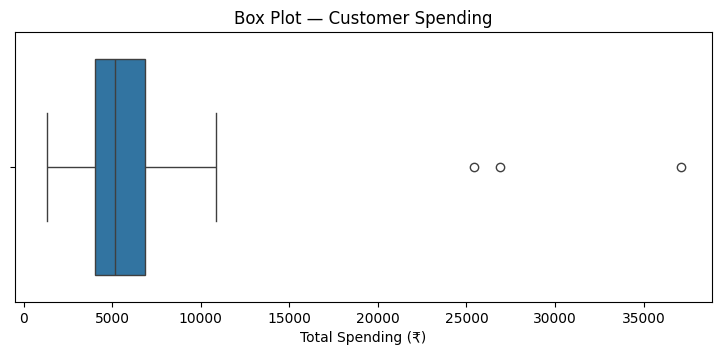

In [25]:

plt.figure(figsize=(9, 3.5))
sns.boxplot(x=df["Total_Spending"])
plt.title("Box Plot — Customer Spending")
plt.xlabel("Total Spending (₹)")
plt.show()


In [26]:

df["Total_Spending"].describe()


,Total_Spending
count,120.00
mean,"5,938.93"
std,"4,414.39"
min,"1,299.00"
25%,"4,059.00"
50%,"5,157.00"
75%,"6,871.00"
max,"37,096.00"



# Part F — Final Mini Challenge

## Business Problem

You are a junior data analyst for an e-commerce company.

The manager asks:

> **"Who is a typical customer, how much do they spend, and are there any unusual customers we should investigate?"**

### Your task

Use the dataset and create a short statistical profile containing:

1. Mean spending
2. Median spending
3. Standard deviation
4. Q1 and Q3
5. IQR
6. Minimum and maximum
7. Number of possible outliers
8. One histogram
9. One box plot

### Final interpretation

Write 4–5 sentences answering:

- What is a typical spending level?
- Is the mean or median more useful here?
- Is spending highly variable?
- Are there possible outliers?
- What should the business investigate next?

**Do not just print the numbers. Explain them.**


Explaination is in the last block



In [27]:
spending = df["Total_Spending"]

summary = {
    "Mean": spending.mean(),
    "Median": spending.median(),
    "Std Dev": spending.std(),
    "Q1": spending.quantile(0.25),
    "Q3": spending.quantile(0.75),
    "IQR": spending.quantile(0.75) - spending.quantile(0.25),
    "Min": spending.min(),
    "Max": spending.max()
}

summary


{'Mean': np.float64(5938.933333333333),
 'Median': 5157.0,
 'Std Dev': 4414.386954084582,
 'Q1': np.float64(4059.0),
 'Q3': np.float64(6871.0),
 'IQR': np.float64(2812.0),
 'Min': 1299.0,
 'Max': 37096.0}

In [28]:


Q1 = spending.quantile(0.25)
Q3 = spending.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

possible_outliers = spending[(spending < lower) | (spending > upper)]

print("Possible outliers:", len(possible_outliers))
print(possible_outliers.sort_values(ascending=False).head(10))


Possible outliers: 3
10   37,096.00
90   26,892.00
45   25,450.00
Name: Total_Spending, dtype: float64


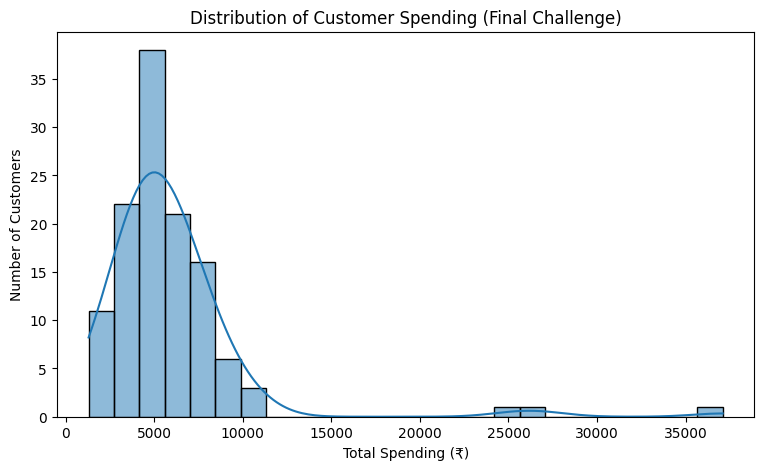

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.histplot(spending, bins=25, kde=True)
plt.title("Distribution of Customer Spending (Final Challenge)")
plt.xlabel("Total Spending (₹)")
plt.ylabel("Number of Customers")
plt.show()

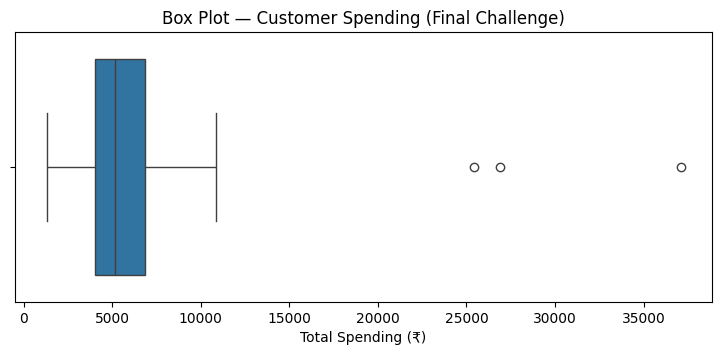

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 3.5))
sns.boxplot(x=spending)
plt.title("Box Plot — Customer Spending (Final Challenge)")
plt.xlabel("Total Spending (₹)")
plt.show()

## Final Interpretation

A typical customer's spending level, as indicated by the median, is around ₹5,157. The mean spending (₹5,938.93) is higher than the median, suggesting a right-skewed distribution. In this case, the median is a more robust and useful measure for "typical" spending because it is less affected by the few extremely high spending customers.

Spending is highly variable, as evidenced by a standard deviation of ₹4,414.39, which is quite large relative to the mean. The IQR of ₹2,812.00 also shows a significant spread in the middle 50% of the data. There are 3 possible outliers identified, with spending significantly higher than the upper bound of ₹11,089.00. The business should investigate these high-spending customers further to understand their purchasing behavior and potentially identify opportunities for targeted marketing or VIP programs.